In [5]:
import pandas as pd

from lib.h_ensemble import build_ensemble_csv
from lib.uncertainty import compute_uncertainties
import numpy as np
# load data 
""" MAIN SETTINGS AND DATA LOADING"""

dataset = 'adni'
analysis_name = 'mci_ad_conversion'
outcome_name = 'label_bl_36m'
build_ensemble_csv(analysis_name, outcome_name, index_col=['subject_id','month'])


all_patients = pd.read_csv(f'../data/{dataset}/adni_baseline_only_36m.csv')



# load all predictions for the full training set (including active patients at bl)
patients_stats = pd.read_csv(f'../results/classification/{analysis_name}/{outcome_name}/aggregated/patient_mean_probs_{outcome_name}_{analysis_name}_model.csv')
patients_stats.set_index(['subject_id', 'month'], inplace=True)



# 1. Extract the inner list from each row using .str[0]
import ast

# 1. Convert the string representation "[0.8, 0.83...]" into a real Python list
real_lists = patients_stats['all_probs'].apply(ast.literal_eval)

# 2. Now expand those lists into columns
probs_raw_df = pd.DataFrame(real_lists.tolist(), index=patients_stats.index)


all_patients.set_index(['subject_id', 'month'], inplace=True)


actual_outcomes = patients_stats['label'].values
mean_probs = patients_stats['mu'].values

Successfully aggregated 9450 predictions across 314 unique patients.


In [6]:
best_tau = 0.54

In [7]:
# Compute uncertainties for the non-active patients at baseline
from scipy.stats import pointbiserialr

tau = best_tau  # This is the threshold we want to test
uncertainty_metrics, tau = compute_uncertainties(probs_raw_df, patients_stats, tau=tau)
predictions = (patients_stats['mu'] >= tau).astype(int)

# Compute error indicator
is_error = (predictions != actual_outcomes).astype(int)

# Test each metric
results = []

for name, metric in uncertainty_metrics.items():
    # For metrics where LOW = uncertain, flip the sign
    if name in ['Margin', 'Distance_to_tau']:
        metric_for_corr = -metric  # Higher values = more uncertain
    else:
        metric_for_corr = metric
    
    # Compute correlation
    r, p_value = pointbiserialr(is_error, metric_for_corr)
    
    results.append({
        'Metric': name,
        'Correlation': r,
        'P-value': p_value,
        'Significant': p_value < 0.05
    })
    
    print(f"{name:25s} | r = {r:6.3f} | p = {p_value:.4f} | {'✓' if p_value < 0.05 else '✗'}")

# Sort by absolute correlation
results_df = pd.DataFrame(results)
results_df['Abs_Correlation'] = results_df['Correlation'].abs()
results_df = results_df.sort_values('Abs_Correlation', ascending=False)

print("\n=== RANKED BY PREDICTIVE POWER ===")
print(results_df.to_string(index=False))



H_total                   | r =  0.377 | p = 0.0000 | ✓
Margin                    | r =  0.387 | p = 0.0000 | ✓
Inverse_Margin            | r =  0.232 | p = 0.0000 | ✓
Ensemble_Variance         | r =  0.337 | p = 0.0000 | ✓
Ensemble_Std              | r =  0.365 | p = 0.0000 | ✓
H_tau_symmetric           | r =  0.379 | p = 0.0000 | ✓
H_tau_imbalanced          | r =  0.194 | p = 0.0006 | ✓
Var_over_margin           | r =  0.234 | p = 0.0000 | ✓
Distance_to_tau           | r =  0.387 | p = 0.0000 | ✓

=== RANKED BY PREDICTIVE POWER ===
           Metric  Correlation      P-value  Significant  Abs_Correlation
           Margin     0.386610 1.234540e-12         True         0.386610
  Distance_to_tau     0.386610 1.234540e-12         True         0.386610
  H_tau_symmetric     0.379043 3.627876e-12         True         0.379043
          H_total     0.376924 4.882600e-12         True         0.376924
     Ensemble_Std     0.364692 2.599755e-11         True         0.364692
Ensemble_Varianc

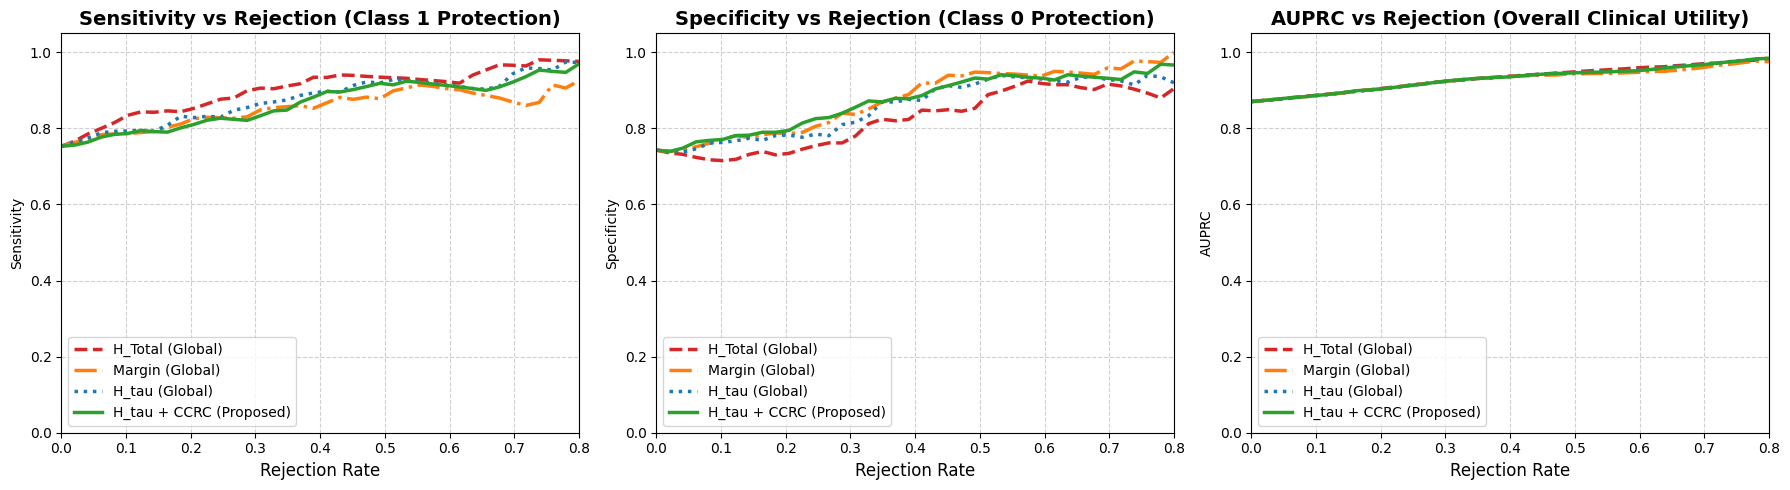

In [9]:
from lib.uncertainty import compute_ablation_metrics
import matplotlib.pyplot as plt

# ==========================================
# EXECUTE THE 4-WAY ABLATION STUDY
# ==========================================
# (Assuming actual_outcomes, mean_probs, best_tau, and your metrics dictionary are already loaded)

# Sweep from 0% to 80% rejection to capture the crashes
reject_rates = np.linspace(0, 0.80, 40) 

# Ensure metrics are oriented so HIGH = Uncertain
h_total_scores = uncertainty_metrics['H_total']
h_tau_scores = uncertainty_metrics['H_tau_symmetric']
margin_scores = -np.abs(mean_probs - best_tau) # Pure Margin inverted: small distance -> high uncertainty

# 1. Standard AI (H_Total Global)
df_htotal_global = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, h_total_scores, reject_rates, mode='global'
)

# 2. Pure Margin Global (The Naive Fix)
df_margin_global = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, margin_scores, reject_rates, mode='global'
)

# 3. Piecewise Entropy Global (The Theoretical Fix)
df_htau_global = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, h_tau_scores, reject_rates, mode='global'
)

# 4. Piecewise Entropy + CCRC (The SOTA Pipeline)
df_htau_ccrc = compute_ablation_metrics(
    actual_outcomes, mean_probs, best_tau, h_tau_scores, reject_rates, mode='ccrc'
)

# ==========================================
# VISUALIZE THE RESULTS
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    ('H_Total (Global)', df_htotal_global, '#d62728', '--'),   # Red, dashed (Standard AI Failure)
    ('Margin (Global)', df_margin_global, '#ff7f0e', '-.'),    # Orange, dash-dot (Runway Failure)
    ('H_tau (Global)', df_htau_global, '#1f77b4', ':'),        # Blue, dotted (Density Failure)
    ('H_tau + CCRC (Proposed)', df_htau_ccrc, '#2ca02c', '-')  # Green, solid (The Fix)
]

for name, df, color, linestyle in configs:
    axes[0].plot(df['Reject_Rate'], df['Sensitivity'], label=name, color=color, linestyle=linestyle, linewidth=2.5)
    axes[1].plot(df['Reject_Rate'], df['Specificity'], label=name, color=color, linestyle=linestyle, linewidth=2.5)
    axes[2].plot(df['Reject_Rate'], df['AUPRC'], label=name, color=color, linestyle=linestyle, linewidth=2.5)

# Formatting Panel 1: Sensitivity (Tracks Minority-Class Erasure)
axes[0].set_title("Sensitivity vs Rejection (Class 1 Protection)", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Sensitivity")

# Formatting Panel 2: Specificity (Tracks Majority-Class Erasure)
axes[1].set_title("Specificity vs Rejection (Class 0 Protection)", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Specificity")

# Formatting Panel 3: AUPRC (Overall Clinical Trajectory)
axes[2].set_title("AUPRC vs Rejection (Overall Clinical Utility)", fontsize=14, fontweight='bold')
axes[2].set_ylabel("AUPRC")

# Universal Formatting
for ax in axes:
    ax.set_xlabel("Rejection Rate", fontsize=12)
    ax.set_xlim([0, 0.80])
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=10, loc='lower left')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## AUGRC Results using Htau + CCRC and Global rejection
Now that we understand the mathematical issues, let's look at the actual AUGRC results when we apply CCRC to both the global risk and the class-specific risks.

In [10]:
# 4. Piecewise Entropy + CCRC (The SOTA Pipeline)
from lib.uncertainty import compute_ablation_metrics2


df_htau_ccrc = compute_ablation_metrics2(
    actual_outcomes, mean_probs, best_tau, h_tau_scores, reject_rates, mode='ccrc'
)

# 1. Standard AI (H_Total Global)
df_htotal_global = compute_ablation_metrics2(
    actual_outcomes, mean_probs, best_tau, h_total_scores, reject_rates, mode='global'
)


In [ ]:
from sklearn.metrics import auc

# Sort by Coverage ascending so auc() integrates correctly
df_sorted = df_htau_ccrc.sort_values(by='Coverage')

coverage = df_sorted['Coverage'].values
global_risk = df_sorted['Global_Gen_Risk'].values
cc_risk_1 = df_sorted['ccGen_Risk_1'].values
cc_risk_0 = df_sorted['ccGen_Risk_0'].values
# Calculate Areas 
global_augrc = auc(coverage, global_risk)
class1_augrc = auc(coverage, cc_risk_1)
class0_augrc = auc(coverage, cc_risk_0)

print(f"Global AUGRC (htau_ccrc): {global_augrc:.4f}")
print(f"Progressor AUGRC (htotal_ccrc): {class1_augrc:.4f}")
print(f"Non progressor AUGRC (htau_ccrc): {class0_augrc:.4f}")

Global AUGRC (htau_ccrc): 0.0752
Progressor AUGRC (htotal_ccrc): 0.0751
Non progressor AUGRC (htau_ccrc): 0.0752


In [12]:
from sklearn.metrics import auc

# Sort by Coverage ascending so auc() integrates correctly
df_sorted = df_htotal_global.sort_values(by='Coverage')

coverage = df_sorted['Coverage'].values
global_risk = df_sorted['Global_Gen_Risk'].values
cc_risk_1 = df_sorted['ccGen_Risk_1'].values
cc_risk_0 = df_sorted['ccGen_Risk_0'].values

# Calculate Areas
global_augrc = auc(coverage, global_risk)
class1_augrc = auc(coverage, cc_risk_1)
class0_augrc = auc(coverage, cc_risk_0)

print(f"Global AUGRC (htotal_global): {global_augrc:.4f}")
print(f"Progressor AUGRC (htotal_global): {class1_augrc:.4f}")
print(f"Non progressor AUGRC (htau_global): {class0_augrc:.4f}")

Global AUGRC (htotal_global): 0.0753
Progressor AUGRC (htotal_global): 0.0583
Non progressor AUGRC (htau_global): 0.0954
